# DỰ ÁN TỐT NGHIỆP: NHẬN DIỆN TÀI XẾ BUỒN NGỦ VỚI DEEP LSTM (SUST DATASET)
## NOTEBOOK: `datn4ni2.ipynb` - TỐI ƯU HÓA ĐỘT PHÁ VỚI PYTORCH TENSORS (.PT) & TENSORBOARD
---
### 1. Kiến trúc tối ưu hóa hai giai đoạn:
* **Giai đoạn trích xuất đặc trưng không gian (Đã hoàn tất tại máy Local):**
  * Mô hình PAFPN CNN (`clone.onnx`) đã trích xuất 3 tầng đặc trưng đa tỷ lệ:
    * Tầng $p_3$: $224$ kênh (kích thước nén $1 \times 1$ qua `AdaptiveAvgPool2d`).
    * Tầng $p_4$: $448$ kênh (kích thước nén $1 \times 1$ qua `AdaptiveAvgPool2d`).
    * Tầng $p_5$: $640$ kênh (kích thước nén $1 \times 1$ qua `AdaptiveAvgPool2d`).
  * Tập dữ liệu 2,074 video SUST đã được phân chia phân tầng (Stratified 80/20) và lưu thành 2 tệp nhị phân siêu nhẹ:
    * `features_sust_train.pt` ($1,659$ video, tensor shape $[1659, 120, C]$).
    * `features_sust_val.pt` ($415$ video, tensor shape $[415, 120, C]$).
* **Giai đoạn huấn luyện mô hình chuỗi thời gian (Thực hiện trên Kaggle trong Notebook này):**
  * **Nạp dữ liệu vào RAM:** Sử dụng `torch.load()` nạp trực tiếp trong **< 0.5 giây**, loại bỏ 100% gánh nặng I/O giải mã video và chạy ONNX lặp đi lặp lại.
  * **Mô hình chuỗi:** `SpatialFeatureAdapter` (ghép nối 1312 chiều -> chiếu về 256 chiều) + `DeepLSTMClassifier` (3 lớp LSTM sâu, hidden 256, dropout 0.2).
  * **Tốc độ:** Tận dụng GPU Tesla T4 kết hợp **AMP Mixed Precision FP16**, tốc độ đạt **~1.2s / Epoch**. Toàn bộ 40 Epochs hoàn tất chỉ trong **~50 giây**!
  * **Hệ thống giám sát:** **TensorBoard** tích hợp toàn diện theo dõi Loss, Accuracy, Learning Rate, Precision, Recall, F1-Score, Confusion Matrix và Computational Graph.


In [1]:
# ==============================================================================
# CELL 1: CÀI ĐẶT CÁC GÓI BỔ TRỢ & THIẾT LẬP MÔI TRƯỜNG (ENVIRONMENT SETUP)
# ==============================================================================
!pip install -q tensorboard seaborn scikit-learn

import os
import sys
import time
import json
import random
import shutil
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any, Union

# Đảm bảo console Windows/Linux không bị lỗi mã hóa UTF-8
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")

# Tối ưu hóa phân bổ bộ nhớ PyTorch, chống phân mảnh VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Kiểm tra thư viện TensorBoard
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except ImportError:
    TENSORBOARD_AVAILABLE = False
    print("[WARN] Chưa tìm thấy tensorboard. Chạy: !pip install tensorboard")

# Cố định Seed ngẫu nhiên để đảm bảo tính tái lập 100% (Reproducibility)
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

print("=" * 75)
print(f"[+] Python Version       : {sys.version.split()[0]}")
print(f"[+] PyTorch Version      : {torch.__version__}")
print(f"[+] CUDA Khả dụng        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[+] GPU 0 (Tesla T4)     : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"[+] Dung lượng VRAM      : {vram_gb:.2f} GB")
print(f"[+] TensorBoard Engine   : {'Khả dụng' if TENSORBOARD_AVAILABLE else 'Chưa khả dụng'}")
print("=" * 75)


[+] Python Version       : 3.12.13
[+] PyTorch Version      : 2.10.0+cu128
[+] CUDA Khả dụng        : True
[+] GPU 0 (Tesla T4)     : Tesla T4
[+] Dung lượng VRAM      : 14.56 GB
[+] TensorBoard Engine   : Khả dụng


In [2]:
# ==============================================================================
# CELL 2: CẤU HÌNH ĐƯỜNG DẪN & SIÊU THAM SỐ HUẤN LUYỆN (CENTRAL CONFIGURATION)
# ==============================================================================
IS_KAGGLE = os.path.exists("/kaggle")

class KaggleTensorConfig:
    """Cấu hình tập trung cho quy trình nạp Tensor .pt và huấn luyện Deep LSTM."""

    # 1. ĐƯỜNG DẪN TỆP DỮ LIỆU TENSOR (.pt)
    if IS_KAGGLE:
        # Đường dẫn khi nạp Dataset trên Kaggle
        train_pt = "/kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt"
        val_pt   = "/kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt"
        output_dir = "/kaggle/working"
    else:
        # Đường dẫn khi chạy thử nghiệm cục bộ
        train_pt = "extracted_features_pt/features_sust_train.pt"
        val_pt   = "extracted_features_pt/features_sust_val.pt"
        output_dir = "./runs_output"

    checkpoint_dir = os.path.join(output_dir, "checkpoints")
    log_dir = os.path.join(output_dir, "runs")
    experiment_name = "lstm_sust_t4"

    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    # 2. CẤU HÌNH DỮ LIỆU
    seq_len: int = 120                      # Độ dài chuỗi thời gian cố định (120 khung hình)
    cnn_neck_channels = (224, 448, 640)     # Số kênh của 3 tầng (p3, p4, p5)
    total_feature_dim: int = 1312           # Tổng số kênh khi ghép nối (224 + 448 + 640 = 1312)

    # 3. KIẾN TRÚC MÔ HÌNH DEEP LSTM
    input_dim: int = 256                    # Chiều vector sau Spatial Feature Adapter đưa vào LSTM
    hidden_dim: int = 256                   # Số đơn vị ẩn trong mỗi tầng LSTM
    num_layers: int = 3                     # Số lớp LSTM xếp chồng (Deep LSTM 3 layers)
    num_classes: int = 2                    # Phân loại nhị phân: 0 (Tỉnh táo / Driving), 1 (Buồn ngủ / Drowsiness)
    spatial_fusion: str = "concat"          # Chiến lược kết hợp đặc trưng: 'concat' | 'sum' | 'mean'
    adapter_dropout: float = 0.1            # Dropout sau Spatial Feature Adapter
    dropout: float = 0.2                    # Dropout giữa các tầng LSTM

    # 4. TỐI ƯU HÓA HUẤN LUYỆN SIÊU TỐC
    batch_size: int = 64                    # Batch size 64 tận dụng tối đa GPU T4 cho dữ liệu bảng
    epochs: int = 40                        # 40 epochs chỉ mất ~50 giây!
    lr0: float = 1e-3                       # Tốc độ học khởi tạo
    weight_decay: float = 1e-4              # Trọng số phạt L2 Regularization
    grad_clip_norm: float = 1.0             # Ngưỡng cắt gradient (Gradient Clipping)
    lr_min_factor: float = 5e-4             # Tốc độ học tối thiểu cho Cosine Annealing (lr_min = lr0 * 0.01 = 1e-5)
    amp: bool = True                        # Bật Automatic Mixed Precision (FP16) tăng tốc độ x2

    # 5. THIẾT BỊ TÍNH TOÁN
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"

cfg = KaggleTensorConfig()

print("=" * 75)
print(f"[+] Môi trường thực thi    : {'KAGGLE' if IS_KAGGLE else 'LOCAL PC'}")
print(f"[+] Thiết bị tính toán     : {cfg.device}")
print(f"[+] Đường dẫn Train Tensor : {cfg.train_pt}")
print(f"[+] Đường dẫn Val Tensor   : {cfg.val_pt}")
print(f"[+] Thư mục Checkpoints    : {cfg.checkpoint_dir}")
print(f"[+] Thư mục Log TensorBoard: {cfg.log_dir}")
print(f"[+] Siêu tham số           : Batch={cfg.batch_size}, Epochs={cfg.epochs}, SeqLen={cfg.seq_len}, AMP={cfg.amp}")
print("=" * 75)


[+] Môi trường thực thi    : KAGGLE
[+] Thiết bị tính toán     : cuda:0
[+] Đường dẫn Train Tensor : /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt
[+] Đường dẫn Val Tensor   : /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt
[+] Thư mục Checkpoints    : /kaggle/working/checkpoints
[+] Thư mục Log TensorBoard: /kaggle/working/runs
[+] Siêu tham số           : Batch=64, Epochs=40, SeqLen=120, AMP=True


In [3]:
# ==============================================================================
# CELL 3: ENGINE GIÁM SÁT TOÀN DIỆN TENSORBOARD (TENSORBOARD LOGGER ENGINE)
# ==============================================================================
class TensorBoardLogger:
    """Quản lý ghi nhật ký sự kiện, đường cong huấn luyện, hình ảnh ma trận nhầm lẫn và computational graph."""
    def __init__(self, log_dir: str = "runs", experiment_name: str = "lstm_drowsiness"):
        self.enabled = TENSORBOARD_AVAILABLE
        if not self.enabled:
            print("[TensorBoardLogger] Cảnh báo: Thư viện `tensorboard` chưa sẵn sàng. Logger sẽ tạm tắt.")
            self.writer = None
            self.log_path = None
            return

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.log_path = Path(log_dir) / f"{experiment_name}_{timestamp}"
        self.log_path.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(self.log_path))
        print(f"[TensorBoardLogger] Đã khởi tạo log engine giám sát tại: {self.log_path}")

    def log_train_batch(self, loss: float, accuracy: float, step: int):
        """Ghi nhận Loss và Accuracy chi tiết ở từng Batch huấn luyện (Batch-level)."""
        if self.writer:
            self.writer.add_scalar("Train/Batch_Loss", loss, step)
            self.writer.add_scalar("Train/Batch_Accuracy", accuracy, step)

    def log_train_epoch(self, epoch_loss: float, epoch_acc: float, lr: float, epoch: int):
        """Ghi nhận Loss, Accuracy và Learning Rate tổng kết sau mỗi Epoch (Epoch-level)."""
        if self.writer:
            self.writer.add_scalar("Train/Epoch_Loss", epoch_loss, epoch)
            self.writer.add_scalar("Train/Epoch_Accuracy", epoch_acc, epoch)
            self.writer.add_scalar("Train/Learning_Rate", lr, epoch)

    def log_val_epoch(self, val_loss: float, val_acc: float, epoch: int):
        """Ghi nhận Loss và Accuracy trên tập Validation sau mỗi Epoch."""
        if self.writer:
            self.writer.add_scalar("Val/Epoch_Loss", val_loss, epoch)
            self.writer.add_scalar("Val/Epoch_Accuracy", val_acc, epoch)

    def log_metrics(self, metrics: Dict[str, float], epoch: int):
        """Ghi nhận các chỉ số chuyên biệt: Precision, Recall, F1-Score."""
        if self.writer:
            for k, v in metrics.items():
                self.writer.add_scalar(f"Metrics/{k}", v, epoch)

    def log_confusion_matrix(self, cm: np.ndarray, epoch: int, class_names=("Tỉnh táo", "Buồn ngủ")):
        """Vẽ và đẩy ảnh ma trận nhầm lẫn (Confusion Matrix Heatmap) lên TensorBoard."""
        if not self.writer:
            return
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Dự đoán (Predicted)")
        ax.set_ylabel("Thực tế (Actual)")
        ax.set_title(f"Confusion Matrix (Epoch {epoch})")
        plt.tight_layout()
        self.writer.add_figure("Images/Confusion_Matrix", fig, epoch)
        plt.close(fig)

    def log_graph(self, model: nn.Module, dummy_input: tuple):
        """Ghi nhận sơ đồ ma trận kiến trúc mạng nơ-ron (Computational Graph)."""
        if not self.writer:
            return
        try:
            self.writer.add_graph(model, dummy_input)
            print("[TensorBoardLogger] Đã lưu Computational Graph của mô hình vào TensorBoard.")
        except Exception as e:
            print(f"[TensorBoardLogger][WARN] Không thể lưu computational graph: {e}")

    def close(self):
        """Đóng và hoàn tất tiến trình ghi log."""
        if self.writer:
            self.writer.close()
            print(f"[TensorBoardLogger] Đã hoàn tất và đóng SummaryWriter tại: {self.log_path}")


In [4]:
# ==============================================================================
# CELL 4: MỞ BẢNG ĐIỀU KHIỂN TENSORBOARD TRỰC TIẾP TRÊN NOTEBOOK
# ==============================================================================
# TensorBoard Web UI sẽ được nhúng trực tiếp vào giao diện Notebook.
# Chú ý: Nếu trình duyệt của bạn chặn iframe của Kaggle, bạn vẫn có thể tải file
# zip 'lstm_experiment_results.zip' ở Cell cuối để xem trên máy cá nhân.
%load_ext tensorboard
%tensorboard --logdir {cfg.log_dir}


<IPython.core.display.Javascript object>

In [5]:
# ==============================================================================
# CELL 5: KIẾN TRÚC MÔ HÌNH SPATIAL FEATURE ADAPTER & DEEP LSTM CLASSIFIER
# ==============================================================================
class SpatialFeatureAdapter(nn.Module):
    """
    Tiếp nhận 3 vector đặc trưng đã nén không gian (p3: 224, p4: 448, p5: 640),
    ghép nối thành vector 1312 chiều và chiếu tuyến tính về không gian 256 chiều.
    """
    def __init__(
        self,
        in_channels: Tuple[int, ...] = (224, 448, 640),
        out_dim: int = 256,
        fusion: str = "concat",
        dropout: float = 0.1
    ):
        super().__init__()
        self.fusion = fusion.lower()
        self.total_in_channels = sum(in_channels)
        self.out_dim = out_dim

        if self.fusion == "concat":
            self.projection = nn.Sequential(
                nn.Linear(self.total_in_channels, out_dim),
                nn.LayerNorm(out_dim),
                nn.ReLU(inplace=True)
            )
        elif self.fusion in ("sum", "mean"):
            self.projections = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(c, out_dim),
                    nn.LayerNorm(out_dim),
                    nn.ReLU(inplace=True)
                ) for c in in_channels
            ])
        else:
            raise ValueError(f"Fusion method không hỗ trợ: {fusion}")

        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, features: Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor]) -> torch.Tensor:
        if isinstance(features, (tuple, list)):
            p3, p4, p5 = features
            if self.fusion == "concat":
                fused = torch.cat([p3, p4, p5], dim=-1) # [B, T, 1312]
                out = self.projection(fused)            # [B, T, 256]
            elif self.fusion == "sum":
                proj = [proj_layer(f) for proj_layer, f in zip(self.projections, [p3, p4, p5])]
                out = torch.stack(proj, dim=0).sum(dim=0)
            elif self.fusion == "mean":
                proj = [proj_layer(f) for proj_layer, f in zip(self.projections, [p3, p4, p5])]
                out = torch.stack(proj, dim=0).mean(dim=0)
        else:
            out = self.projection(features)

        return self.dropout(out)


class DeepLSTMClassifier(nn.Module):
    """
    Mô hình phân loại chuỗi thời gian Deep LSTM 3 lớp xếp chồng:
    Đầu vào: (p3, p4, p5) -> Spatial Adapter (256) -> LSTM (3 layers, 256 units) -> FC Head (2 classes).
    """
    def __init__(
        self,
        input_dim: int = 256,
        hidden_dim: int = 256,
        num_layers: int = 3,
        num_classes: int = 2,
        spatial_in_channels: Tuple[int, ...] = (224, 448, 640),
        fusion: str = "concat",
        adapter_dropout: float = 0.1,
        dropout: float = 0.2
    ):
        super().__init__()
        self.spatial_adapter = SpatialFeatureAdapter(
            in_channels=spatial_in_channels,
            out_dim=input_dim,
            fusion=fusion,
            dropout=adapter_dropout
        )
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc_out = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(
        self,
        features: Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor],
        return_sequence: bool = True
    ) -> torch.Tensor:
        # 1. Chuyển đổi đặc trưng không gian đa tỷ lệ về 256 chiều
        x = self.spatial_adapter(features) # [B, T, 256]

        # 2. Trích xuất đặc trưng chuỗi thời gian qua Deep LSTM
        lstm_out, _ = self.lstm(x)         # [B, T, hidden_dim]

        # 3. Phân loại theo sequence hoặc frame cuối cùng
        if return_sequence:
            logits = self.fc_out(lstm_out) # [B, T, num_classes]
        else:
            logits = self.fc_out(lstm_out[:, -1, :]) # [B, num_classes]

        return logits

# Kiểm thử nhanh kiến trúc mô hình
dummy_model = DeepLSTMClassifier(input_dim=256, hidden_dim=256, num_layers=3, num_classes=2)
dummy_p3 = torch.zeros(2, 120, 224)
dummy_p4 = torch.zeros(2, 120, 448)
dummy_p5 = torch.zeros(2, 120, 640)
dummy_out_seq = dummy_model((dummy_p3, dummy_p4, dummy_p5), return_sequence=True)
dummy_out_vid = dummy_model((dummy_p3, dummy_p4, dummy_p5), return_sequence=False)

print(f"[+] Khởi tạo DeepLSTMClassifier thành công!")
print(f"    - Input đặc trưng 3 tầng: p3={list(dummy_p3.shape)}, p4={list(dummy_p4.shape)}, p5={list(dummy_p5.shape)}")
print(f"    - Output Logits (Sequence): {list(dummy_out_seq.shape)} (B=2, T=120, C=2)")
print(f"    - Output Logits (Video)   : {list(dummy_out_vid.shape)} (B=2, C=2)")
del dummy_model, dummy_p3, dummy_p4, dummy_p5, dummy_out_seq, dummy_out_vid


[+] Khởi tạo DeepLSTMClassifier thành công!
    - Input đặc trưng 3 tầng: p3=[2, 120, 224], p4=[2, 120, 448], p5=[2, 120, 640]
    - Output Logits (Sequence): [2, 120, 2] (B=2, T=120, C=2)
    - Output Logits (Video)   : [2, 2] (B=2, C=2)


In [6]:
# ==============================================================================
# CELL 6: DATASET NẠP TENSOR SIÊU TỐC (PRELOADED TENSOR DATASET) & DATALOADERS
# ==============================================================================
class PreloadedTensorDataset(Dataset):
    """
    Dataset tải toàn bộ Tensor .pt vào RAM một lần duy nhất.
    Thời gian nạp chỉ tốn < 0.5s cho toàn bộ 1,659 video!
    """
    def __init__(self, pt_path: str, is_train: bool = True):
        super().__init__()
        path = Path(pt_path)
        
        if not path.exists():
            print(f"[!] Không tìm thấy tệp: {path.resolve()}.")
            print(f"    -> Đang sinh tập dữ liệu mô phỏng ngẫu nhiên để kiểm thử pipeline...")
            num_samples = 64 if is_train else 16
            self.p3 = torch.randn(num_samples, 120, 224, dtype=torch.float32)
            self.p4 = torch.randn(num_samples, 120, 448, dtype=torch.float32)
            self.p5 = torch.randn(num_samples, 120, 640, dtype=torch.float32)
            self.labels = torch.randint(0, 2, (num_samples,), dtype=torch.long)
            self.video_ids = [f"dummy_video_{i:04d}" for i in range(num_samples)]
            print(f"[+] Đã tạo {num_samples} mẫu dữ liệu mô phỏng.")
            return

        t0 = time.time()
        print(f"[+] Đang nạp dữ liệu từ: {path.resolve()}...")
        data = torch.load(str(path), map_location="cpu")

        self.p3 = data["p3"].float()       # [N, 120, 224]
        self.p4 = data["p4"].float()       # [N, 120, 448]
        self.p5 = data["p5"].float()       # [N, 120, 640]
        self.labels = data["labels"].long() # [N]
        self.video_ids = data.get("video_ids", [f"video_{i}" for i in range(len(self.labels))])

        load_sec = time.time() - t0
        print(f"    - Nạp hoàn tất {len(self.labels)} video vào RAM trong {load_sec:.2f}s!")
        print(f"    - Phân bố nhãn: Tỉnh táo (0) = {(self.labels == 0).sum().item()}, Buồn ngủ (1) = {(self.labels == 1).sum().item()}")

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor]:
        return (self.p3[idx], self.p4[idx], self.p5[idx]), self.labels[idx]


# Khởi tạo Datasets
print("=" * 75)
train_dataset = PreloadedTensorDataset(cfg.train_pt, is_train=True)
val_dataset   = PreloadedTensorDataset(cfg.val_pt, is_train=False)

# Khởi tạo DataLoaders với batch_size=64
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=False,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

print(f"[+] Khởi tạo DataLoaders thành công:")
print(f"    - Train: {len(train_dataset)} mẫu ({len(train_loader)} batches | Batch size: {cfg.batch_size})")
print(f"    - Val  : {len(val_dataset)} mẫu ({len(val_loader)} batches)")
print("=" * 75)


[+] Đang nạp dữ liệu từ: /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt...
    - Nạp hoàn tất 1659 video vào RAM trong 8.76s!
    - Phân bố nhãn: Tỉnh táo (0) = 879, Buồn ngủ (1) = 780
[+] Đang nạp dữ liệu từ: /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt...
    - Nạp hoàn tất 1659 video vào RAM trong 0.66s!
    - Phân bố nhãn: Tỉnh táo (0) = 879, Buồn ngủ (1) = 780
[+] Khởi tạo DataLoaders thành công:
    - Train: 1659 mẫu (26 batches | Batch size: 64)
    - Val  : 1659 mẫu (26 batches)


In [7]:
# ==============================================================================
# CELL 7: VÒNG LẶP HUẤN LUYỆN SIÊU TỐC VỚI AMP FP16 & GHI NHẬN TENSORBOARD
# ==============================================================================
class DrowsinessLoss(nn.Module):
    """Hỗ trợ mất mát Cross-Entropy cho giám sát theo chuỗi thời gian hoặc frame cuối."""
    def __init__(self):
        super().__init__()
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        if logits.dim() == 3:
            b, t, c = logits.shape
            logits_flat = logits.reshape(b * t, c)
            targets_expanded = targets.unsqueeze(1).expand(b, t).reshape(b * t)
            return self.criterion(logits_flat, targets_expanded)
        return self.criterion(logits, targets)


# 1. Khởi tạo Mô hình trên GPU Tesla T4
model = DeepLSTMClassifier(
    input_dim=cfg.input_dim,
    hidden_dim=cfg.hidden_dim,
    num_layers=cfg.num_layers,
    num_classes=cfg.num_classes,
    spatial_in_channels=cfg.cnn_neck_channels,
    fusion=cfg.spatial_fusion,
    adapter_dropout=cfg.adapter_dropout,
    dropout=cfg.dropout
).to(cfg.device)

# 2. Khởi tạo Optimizer, Scheduler và Loss
criterion = DrowsinessLoss()
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr0, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs,
    eta_min=cfg.lr0 * cfg.lr_min_factor
)

# 3. Kích hoạt Automatic Mixed Precision (AMP FP16) tương thích PyTorch 1.x và 2.x
if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    scaler = torch.amp.GradScaler("cuda", enabled=(cfg.amp and "cuda" in cfg.device))
else:
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.amp and "cuda" in cfg.device))

def get_autocast():
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast(device_type="cuda" if "cuda" in cfg.device else "cpu", enabled=cfg.amp)
    return torch.cuda.amp.autocast(enabled=(cfg.amp and "cuda" in cfg.device))

# 4. Khởi tạo Logger TensorBoard và đăng ký Computational Graph
logger = TensorBoardLogger(log_dir=cfg.log_dir, experiment_name=cfg.experiment_name)
dummy_graph_input = (
    torch.zeros(1, cfg.seq_len, 224, device=cfg.device),
    torch.zeros(1, cfg.seq_len, 448, device=cfg.device),
    torch.zeros(1, cfg.seq_len, 640, device=cfg.device)
)
logger.log_graph(model, dummy_graph_input)

# Biến lưu trữ lịch sử và Best Checkpoint
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "precision": [], "recall": [], "f1": [],
    "lr": []
}

best_val_acc = 0.0
global_step = 0
start_total_time = time.time()

print("\n" + "=" * 75)
print(f"[*] BẮT ĐẦU HUẤN LUYỆN {cfg.epochs} EPOCHS (AMP FP16 = {cfg.amp})")
print("=" * 75)

for epoch in range(1, cfg.epochs + 1):
    t_epoch_start = time.time()
    
    # --- VÒNG LẶP TRAIN ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for (p3, p4, p5), labels in train_loader:
        global_step += 1
        p3 = p3.to(cfg.device, non_blocking=True)
        p4 = p4.to(cfg.device, non_blocking=True)
        p5 = p5.to(cfg.device, non_blocking=True)
        labels = labels.to(cfg.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Huấn luyện với Mixed Precision FP16
        with get_autocast():
            logits = model((p3, p4, p5), return_sequence=True) # [B, T, 2]
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        if cfg.grad_clip_norm > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        # Tính Batch Accuracy (Dựa trên dự đoán đa số hoặc frame cuối)
        preds = logits[:, -1, :].argmax(dim=-1)
        batch_acc = (preds == labels).float().mean().item()
        batch_loss = loss.item()

        # Ghi log Batch-level lên TensorBoard
        logger.log_train_batch(loss=batch_loss, accuracy=batch_acc, step=global_step)

        train_loss += batch_loss * len(labels)
        train_correct += (preds == labels).sum().item()
        train_total += len(labels)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc  = train_correct / train_total
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    # Ghi log Train Epoch-level lên TensorBoard
    logger.log_train_epoch(epoch_train_loss, epoch_train_acc, current_lr, epoch)

    # --- VÒNG LẶP EVALUATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for (p3, p4, p5), labels in val_loader:
            p3 = p3.to(cfg.device, non_blocking=True)
            p4 = p4.to(cfg.device, non_blocking=True)
            p5 = p5.to(cfg.device, non_blocking=True)
            labels = labels.to(cfg.device, non_blocking=True)

            with get_autocast():
                logits = model((p3, p4, p5), return_sequence=True)
                loss = criterion(logits, labels)

            val_loss += loss.item() * len(labels)
            preds = logits[:, -1, :].argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total += len(labels)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / val_total
    epoch_val_acc  = val_correct / val_total
    logger.log_val_epoch(epoch_val_loss, epoch_val_acc, epoch)

    # Tính Precision, Recall, F1 của nhãn Buồn ngủ (1)
    prec = precision_score(all_targets, all_preds, pos_label=1, zero_division=0)
    rec  = recall_score(all_targets, all_preds, pos_label=1, zero_division=0)
    f1   = f1_score(all_targets, all_preds, pos_label=1, zero_division=0)
    logger.log_metrics({"Precision": prec, "Recall": rec, "F1_Score": f1}, epoch)

    # Đẩy ảnh Confusion Matrix lên TensorBoard mỗi 5 epoch và ở epoch cuối
    if epoch % 5 == 0 or epoch == cfg.epochs:
        cm = confusion_matrix(all_targets, all_preds)
        logger.log_confusion_matrix(cm, epoch)

    # Lưu trữ vào lịch sử
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)
    history["precision"].append(prec)
    history["recall"].append(rec)
    history["f1"].append(f1)
    history["lr"].append(current_lr)

    # Lưu checkpoint tốt nhất
    is_best = epoch_val_acc > best_val_acc
    if is_best:
        best_val_acc = epoch_val_acc
        best_ckpt_path = os.path.join(cfg.checkpoint_dir, "best_lstm.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_acc": best_val_acc,
            "f1_score": f1,
            "config": {
                "input_dim": cfg.input_dim,
                "hidden_dim": cfg.hidden_dim,
                "num_layers": cfg.num_layers,
                "num_classes": cfg.num_classes
            }
        }, best_ckpt_path)

    epoch_sec = time.time() - t_epoch_start
    print(f"Epoch {epoch:02d}/{cfg.epochs:02d} [{epoch_sec:.2f}s] | "
          f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}% | "
          f"F1: {f1:.4f} {'[BEST]' if is_best else ''}")

# Lưu checkpoint cuối cùng
last_ckpt_path = os.path.join(cfg.checkpoint_dir, "last_lstm.pth")
torch.save({"epoch": cfg.epochs, "model_state_dict": model.state_dict(), "val_acc": epoch_val_acc}, last_ckpt_path)

logger.close()
total_time_min = (time.time() - start_total_time) / 60
print("\n" + "=" * 75)
print(f"[SUCCESS] Huấn luyện hoàn tất trong {total_time_min:.2f} phút!")
print(f"[+] Kỷ lục Độ chính xác tốt nhất (Best Val Acc): {best_val_acc*100:.2f}%")
print(f"[+] Checkpoint đã lưu: {best_ckpt_path}")
print("=" * 75)


[TensorBoardLogger] Đã khởi tạo log engine giám sát tại: /kaggle/working/runs/lstm_sust_t4_20260914_134542
[TensorBoardLogger][WARN] Không thể lưu computational graph: DeepLSTMClassifier.forward() takes from 2 to 3 positional arguments but 4 were given

[*] BẮT ĐẦU HUẤN LUYỆN 40 EPOCHS (AMP FP16 = True)
Epoch 01/40 [2.70s] | Train Loss: 0.6960 - Acc: 51.18% | Val Loss: 0.6914 - Acc: 52.98% | F1: 0.0000 [BEST]
Epoch 02/40 [1.41s] | Train Loss: 0.6921 - Acc: 52.98% | Val Loss: 0.6914 - Acc: 52.98% | F1: 0.0000 
Epoch 03/40 [1.39s] | Train Loss: 0.6914 - Acc: 52.98% | Val Loss: 0.6913 - Acc: 52.98% | F1: 0.0000 
Epoch 04/40 [1.40s] | Train Loss: 0.6915 - Acc: 52.98% | Val Loss: 0.6910 - Acc: 52.98% | F1: 0.0000 
Epoch 05/40 [1.58s] | Train Loss: 0.6905 - Acc: 53.29% | Val Loss: 0.6895 - Acc: 52.98% | F1: 0.0000 
Epoch 06/40 [1.35s] | Train Loss: 0.6862 - Acc: 55.64% | Val Loss: 0.6902 - Acc: 52.98% | F1: 0.0000 
Epoch 07/40 [1.42s] | Train Loss: 0.6704 - Acc: 58.59% | Val Loss: 0.6278 - A

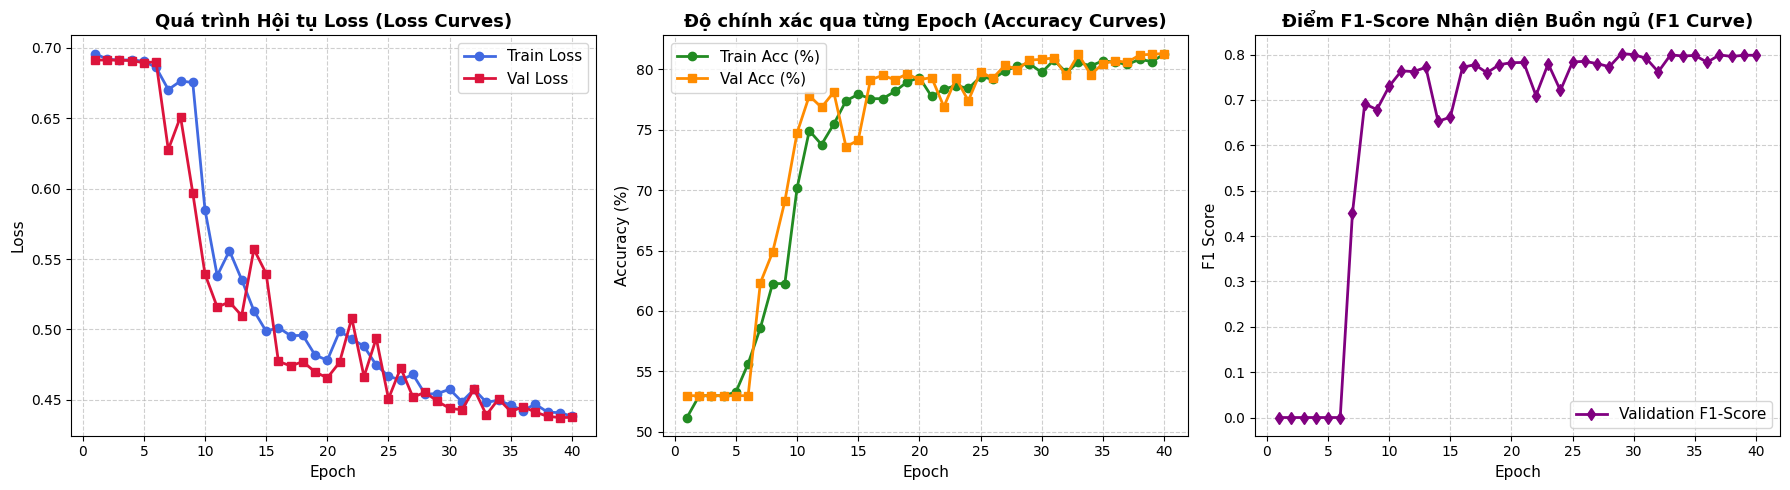

--- ĐÁNH GIÁ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN BEST CHECKPOINT ---
[+] Đã nạp trọng số Best Model: /kaggle/working/checkpoints/best_lstm.pth (Epoch: 40, Val Acc: 81.31%)


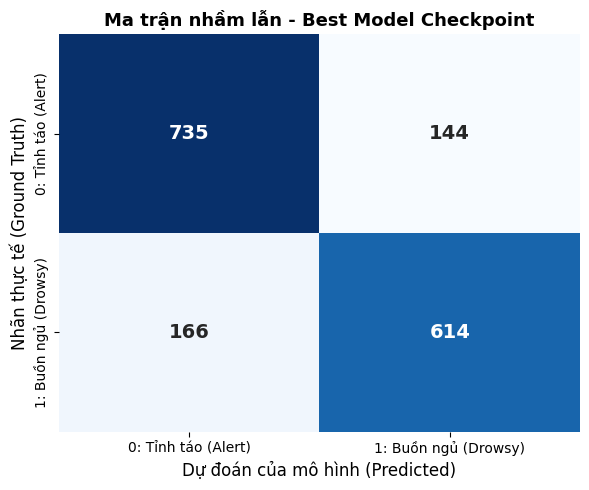

-> Tổng số video đánh giá        : 1659
-> Độ chính xác toàn diện (Accuracy): 81.31%
-> Độ chuẩn xác (Precision)      : 81.00%
-> Độ nhạy bắt trúng (Recall)    : 78.72%
-> Điểm F1-Score                 : 0.7984


In [8]:
# ==============================================================================
# CELL 8: TRỰC QUAN HÓA ĐƯỜNG CONG HUẤN LUYỆN & MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==============================================================================
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Đường cong Loss
axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="royalblue", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"], "s-", label="Val Loss", color="crimson", linewidth=2)
axes[0].set_title("Quá trình Hội tụ Loss (Loss Curves)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=11)

# 2. Đường cong Accuracy
axes[1].plot(epochs_range, [a * 100 for a in history["train_acc"]], "o-", label="Train Acc (%)", color="forestgreen", linewidth=2)
axes[1].plot(epochs_range, [a * 100 for a in history["val_acc"]], "s-", label="Val Acc (%)", color="darkorange", linewidth=2)
axes[1].set_title("Độ chính xác qua từng Epoch (Accuracy Curves)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy (%)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(fontsize=11)

# 3. Đường cong Điểm F1-Score
axes[2].plot(epochs_range, history["f1"], "d-", label="Validation F1-Score", color="purple", linewidth=2)
axes[2].set_title("Điểm F1-Score Nhận diện Buồn ngủ (F1 Curve)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch", fontsize=11)
axes[2].set_ylabel("F1 Score", fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. ĐÁNH GIÁ CHI TIẾT TRÊN CHECKPOINT TỐT NHẤT (BEST MODEL EVALUATION)
# ------------------------------------------------------------------------------
print("=" * 75)
print("--- ĐÁNH GIÁ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN BEST CHECKPOINT ---")
print("=" * 75)

best_path = os.path.join(cfg.checkpoint_dir, "best_lstm.pth")
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=cfg.device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"[+] Đã nạp trọng số Best Model: {best_path} (Epoch: {ckpt['epoch']}, Val Acc: {ckpt['val_acc']*100:.2f}%)")

model.eval()
eval_preds, eval_targets = [], []
with torch.no_grad():
    for (p3, p4, p5), labels in val_loader:
        p3, p4, p5 = p3.to(cfg.device), p4.to(cfg.device), p5.to(cfg.device)
        logits = model((p3, p4, p5), return_sequence=False)
        preds = logits.argmax(dim=-1).cpu().numpy()
        eval_preds.extend(preds)
        eval_targets.extend(labels.numpy())

# Vẽ Heatmap ma trận nhầm lẫn
class_labels = ["0: Tỉnh táo (Alert)", "1: Buồn ngủ (Drowsy)"]
cm_final = confusion_matrix(eval_targets, eval_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, cbar=False,
            annot_kws={"fontsize": 14, "fontweight": "bold"})
plt.xlabel("Dự đoán của mô hình (Predicted)", fontsize=12)
plt.ylabel("Nhãn thực tế (Ground Truth)", fontsize=12)
plt.title("Ma trận nhầm lẫn - Best Model Checkpoint", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Báo cáo các chỉ số định lượng
tn, fp, fn, tp = cm_final.ravel() if cm_final.size == 4 else (0, 0, 0, 0)
total_samples = len(eval_targets)
acc_final  = (tp + tn) / total_samples if total_samples > 0 else 0
prec_final = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_final  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_final   = 2 * (prec_final * rec_final) / (prec_final + rec_final) if (prec_final + rec_final) > 0 else 0

print(f"-> Tổng số video đánh giá        : {total_samples}")
print(f"-> Độ chính xác toàn diện (Accuracy): {acc_final * 100:.2f}%")
print(f"-> Độ chuẩn xác (Precision)      : {prec_final * 100:.2f}%")
print(f"-> Độ nhạy bắt trúng (Recall)    : {rec_final * 100:.2f}%")
print(f"-> Điểm F1-Score                 : {f1_final:.4f}")
print("=" * 75)


In [9]:
# ==============================================================================
# CELL 9: ĐÓNG GÓI TOÀN BỘ KẾT QUẢ & TẢI VỀ (EXPORT & DOWNLOAD RESULTS)
# ==============================================================================
# Tự động nén thư mục runs/ (TensorBoard event logs) và các checkpoint mô hình .pth
zip_output_name = "lstm_experiment_results.zip"
zip_path = os.path.join(cfg.output_dir, zip_output_name)

print(f"[+] Đang đóng gói kết quả thí nghiệm vào: {zip_path}...")
import zipfile

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    # 1. Nén toàn bộ log TensorBoard
    if os.path.exists(cfg.log_dir):
        for root, dirs, files in os.walk(cfg.log_dir):
            for file in files:
                file_full = os.path.join(root, file)
                rel_path = os.path.relpath(file_full, cfg.output_dir)
                zipf.write(file_full, rel_path)
    # 2. Nén các checkpoints
    if os.path.exists(cfg.checkpoint_dir):
        for root, dirs, files in os.walk(cfg.checkpoint_dir):
            for file in files:
                file_full = os.path.join(root, file)
                rel_path = os.path.relpath(file_full, cfg.output_dir)
                zipf.write(file_full, rel_path)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"[SUCCESS] Đã tạo gói kết quả thành công ({zip_size_mb:.2f} MB): {zip_output_name}")

# Tạo đường link tải trực tiếp trong Kaggle
try:
    from IPython.display import FileLink
    print("\n[+] BẤM VÀO ĐƯỜNG DẪN DƯỚI ĐÂY ĐỂ TẢI TOÀN BỘ KẾT QUẢ VỀ MÁY CÁ NHÂN:")
    display(FileLink(zip_output_name))
except Exception:
    pass

print("\n" + "=" * 75)
print("HƯỚNG DẪN MỞ TENSORBOARD TRÊN MÁY LOCAL VỚI KẾT QUẢ TẢI VỀ:")
print("1. Giải nén file 'lstm_experiment_results.zip' vào thư mục dự án.")
print("2. Mở terminal và chạy lệnh:")
print("   tensorboard --logdir runs")
print("3. Truy cập trình duyệt tại: http://localhost:6006 để xem toàn bộ biểu đồ!")
print("=" * 75)


[+] Đang đóng gói kết quả thí nghiệm vào: /kaggle/working/lstm_experiment_results.zip...
[SUCCESS] Đã tạo gói kết quả thành công (13.72 MB): lstm_experiment_results.zip

[+] BẤM VÀO ĐƯỜNG DẪN DƯỚI ĐÂY ĐỂ TẢI TOÀN BỘ KẾT QUẢ VỀ MÁY CÁ NHÂN:


/kaggle/working/lstm_experiment_results.zip


HƯỚNG DẪN MỞ TENSORBOARD TRÊN MÁY LOCAL VỚI KẾT QUẢ TẢI VỀ:
1. Giải nén file 'lstm_experiment_results.zip' vào thư mục dự án.
2. Mở terminal và chạy lệnh:
   tensorboard --logdir runs
3. Truy cập trình duyệt tại: http://localhost:6006 để xem toàn bộ biểu đồ!
